In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

def read_json_data(num):
    df = pd.read_json(f"../data/analysis_{num}.json")
    # flatten 'patterns' array into rows
    df_patterns = df.explode('patterns').dropna(subset=['patterns'])
    # flatten objects {pattern, count} into columns
    df_patterns[['pattern', 'count']] = df_patterns['patterns'].apply(pd.Series)
    return df, df_patterns
    
def pattern_summary(df_patterns):
    pattern_count = df_patterns['pattern'].unique().size
    print(f"Number of unique patterns: {pattern_count}")
    
    # number of unique repos per pattern
    pattern_counts = df_patterns.groupby('pattern')['full_name'].nunique().sort_values(ascending=False)
    print(pattern_counts)

    # total occurences per pattern
    pattern_totals = df_patterns.groupby('pattern')['count'].sum().sort_values(ascending=False)
    print(pattern_totals)
    
def analyze_sample(num: int):
    df, df_patterns = read_json_data(num)
    
    print(f"Total repos: {len(df)}")
    print(f"Repos with at least one pattern: {df['patterns'].apply(len).gt(0).sum()}")
    print(f"Repos with no patterns: {df['patterns'].apply(len).eq(0).sum()}")
    
    pattern_summary(df_patterns)

In [2]:
def outlier_analysis(num: int):
    df = pd.read_json(f"../data/analysis_{num}.json")
    df_patterns = df.explode('patterns').dropna(subset=['patterns'])
    df_patterns[['pattern', 'count']] = df_patterns['patterns'].apply(pd.Series)
    
    plt.figure(figsize=(14, 6))
    sns.boxplot(
        data=df_patterns,
        x='pattern',
        y='count',
        order=df_patterns.groupby('pattern')['count'].median().sort_values(ascending=False).index
    )
    plt.xticks(rotation=45, ha='right')
    plt.yscale('log')
    plt.title(f"Distribution of pattern occurrence counts per repo (v{num})")
    plt.tight_layout()
    plt.savefig(f"outlier_analysis_{num}.png", dpi=150)
    plt.show()


In [47]:
def effectiveness_comparison(comp1, comp2):
    stats = {}
    idx1 = f"v{comp1}"
    idx2 = f"v{comp2}"
    for i in [comp1, comp2]:
        idx = f"v{i}"
        df = pd.read_json(f"../data/analysis_{i}.json")
        df_patterns = df.explode('patterns').dropna(subset=['patterns'])
        df_patterns[['pattern', 'count']] = df_patterns['patterns'].apply(pd.Series)
        stats[idx] = {
            'repos_with_hits': df_patterns['full_name'].nunique(),
            'total_hits': df_patterns['count'].sum(),
            'mean_count': df_patterns['count'].mean(),
            'std_count': df_patterns['count'].std(),
            'df': df_patterns,
            'repos': set(df_patterns['full_name'].unique())
        }

    # Repos present in v1 but missing in v2
    lost_repos = stats[idx1]['repos'] - stats[idx2]['repos']
    gained_repos = stats[idx2]['repos'] - stats[idx1]['repos']

    print(f"\n=== Repo differences ({idx1} -> {idx2}) ===")
    print(f"Repos lost:   {len(lost_repos)}")
    print(f"Repos gained: {len(gained_repos)}")

    if lost_repos:
        print(f"\nLost repos and their patterns in {idx1}:")
        df1 = stats[idx1]['df']
        for repo in sorted(lost_repos):
            patterns = df1[df1['full_name'] == repo][['pattern', 'count']].values.tolist()
            print(f"  {repo}:")
            for pattern, count in sorted(patterns, key=lambda x: x[1], reverse=True):
                print(f"    {pattern:<35} {count}")

    if gained_repos:
        print(f"\nGained repos and their patterns in {idx2}:")
        df2 = stats[idx2]['df']
        for repo in sorted(gained_repos):
            patterns = df2[df2['full_name'] == repo][['pattern', 'count']].values.tolist()
            print(f"  {repo}:")
            for pattern, count in sorted(patterns, key=lambda x: x[1], reverse=True):
                print(f"    {pattern:<35} {count}")

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
    coverage = {v: s['repos_with_hits'] for v, s in stats.items()}
    ax1.bar(coverage.keys(), coverage.values(), color=['steelblue', 'seagreen'])
    ax1.set_title("Repos with at least one pattern hit")
    ax1.set_ylabel("Number of repos")

    combined = pd.concat([
        stats[idx1]['df'].assign(version=idx1),
        stats[idx2]['df'].assign(version=idx2)
    ])
    false_positives = ['reduce', 'unzip', 'ThreadPool', 'ThreadPoolBuilder']
    combined_clean = combined[~combined['pattern'].isin(false_positives)]

    sns.boxplot(data=combined_clean, x='version', y='count', ax=ax2)
    ax2.set_yscale('log')
    ax2.set_title("Count distribution")
    ax2.set_ylabel("Occurrence count (log scale)")
    plt.suptitle("Pattern refinement: coverage vs variance", fontsize=13)
    plt.tight_layout()
    plt.savefig(f"effectiveness_comparison_{comp1}_{comp2}.png", dpi=150)
    plt.show()

In [48]:
analyze_sample(1)

Total repos: 172
Repos with at least one pattern: 169
Repos with no patterns: 3
Number of unique patterns: 19
pattern
reduce                   143
par_iter                 142
unzip                     91
ThreadPool                85
ThreadPoolBuilder         82
par_bridge                39
par_sort                  31
rayon::spawn              31
rayon::scope              25
par_chunks                24
rayon::join               20
par_sort_by               16
impl ParallelIterator     11
flat_map_iter              9
par_extend                 9
par_sort_by_key            6
rayon::broadcast           2
scope_fifo                 2
par_windows                1
Name: full_name, dtype: int64
pattern
reduce                   16985
par_iter                  3339
ThreadPool                1349
unzip                     1293
ThreadPoolBuilder          551
par_sort                   254
par_chunks                 213
par_bridge                 151
par_extend                 104
rayon::spawn  

In [49]:
analyze_sample(2)

Total repos: 172
Repos with at least one pattern: 156
Repos with no patterns: 16
Number of unique patterns: 11
pattern
.par_iter()                 142
rayon::ThreadPool            75
rayon::ThreadPoolBuilder     73
.par_bridge()                39
.par_sort()                  31
rayon::spawn                 31
rayon::scope                 25
rayon::join                  20
impl ParallelIterator        11
rayon::broadcast              2
rayon::scope_fifo             2
Name: full_name, dtype: int64
pattern
.par_iter()                 3333
rayon::ThreadPool            381
.par_sort()                  254
rayon::ThreadPoolBuilder     245
.par_bridge()                151
rayon::spawn                  94
rayon::join                   91
rayon::scope                  71
impl ParallelIterator         29
rayon::scope_fifo              4
rayon::broadcast               2
Name: count, dtype: int64


In [50]:
analyze_sample(3)

Total repos: 172
Repos with at least one pattern: 158
Repos with no patterns: 14
Number of unique patterns: 17
pattern
.par_iter                   142
rayon::ThreadPool            75
rayon::ThreadPoolBuilder     73
.par_bridge                  39
.par_sort                    31
rayon::spawn                 31
rayon::scope                 25
.par_chunks                  24
rayon::join                  20
.par_sort_by                 16
impl ParallelIterator        11
.flat_map_iter                9
.par_extend                   9
.par_sort_by_key              6
rayon::broadcast              2
rayon::scope_fifo             2
.par_windows                  1
Name: full_name, dtype: int64
pattern
.par_iter                   3333
rayon::ThreadPool            381
.par_sort                    254
rayon::ThreadPoolBuilder     245
.par_chunks                  213
.par_bridge                  151
.par_extend                  104
rayon::spawn                  94
rayon::join                   91
ra

In [51]:
analyze_sample(4)

Total repos: 172
Repos with at least one pattern: 154
Repos with no patterns: 18
Number of unique patterns: 13
pattern
\.par_iter                  114
\.into_par_iter              98
rayon::ThreadPoolBuilder     73
\.par_bridge                 39
\.par_chunks                 23
rayon::join                  20
impl ParallelIterator        11
\.par_extend                  9
\.flat_map_iter               9
\.par_sort_by_key             6
rayon::broadcast              2
rayon::scope_fifo             2
\.par_windows                 1
Name: full_name, dtype: int64
pattern
\.par_iter                  1562
\.into_par_iter             1253
rayon::ThreadPoolBuilder     245
\.par_chunks                 195
\.par_bridge                 119
rayon::join                   91
\.par_extend                  50
impl ParallelIterator         29
\.flat_map_iter               18
\.par_sort_by_key             13
\.par_windows                 10
rayon::scope_fifo              4
rayon::broadcast               

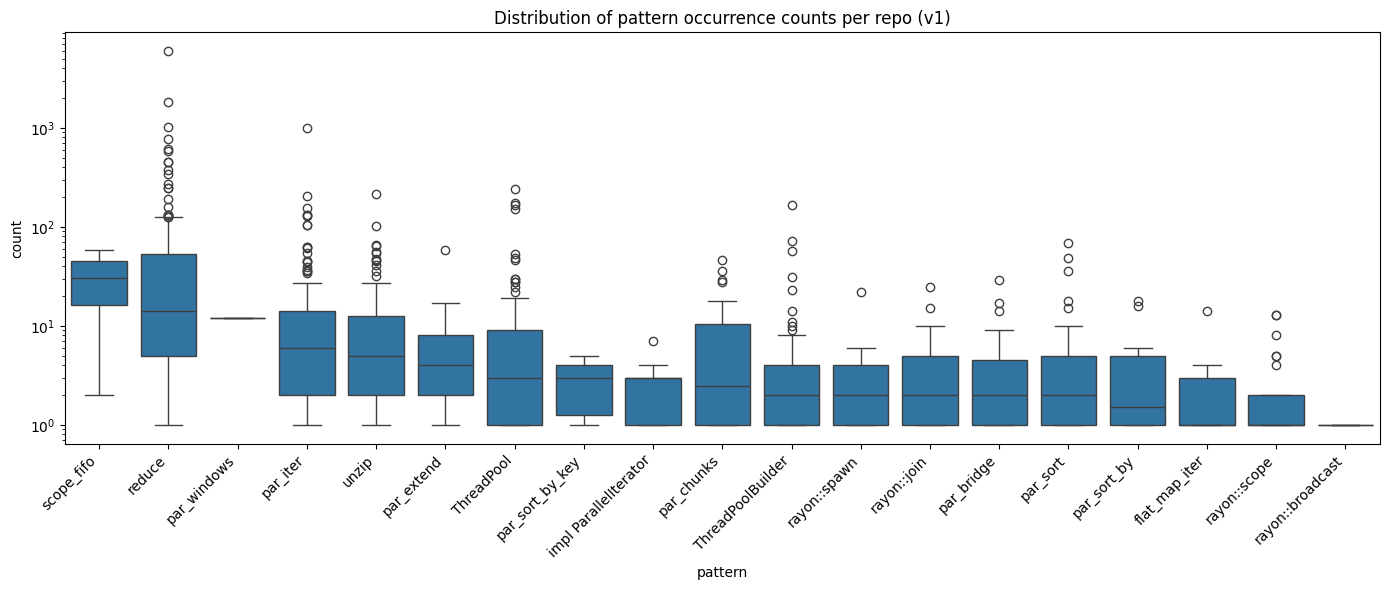

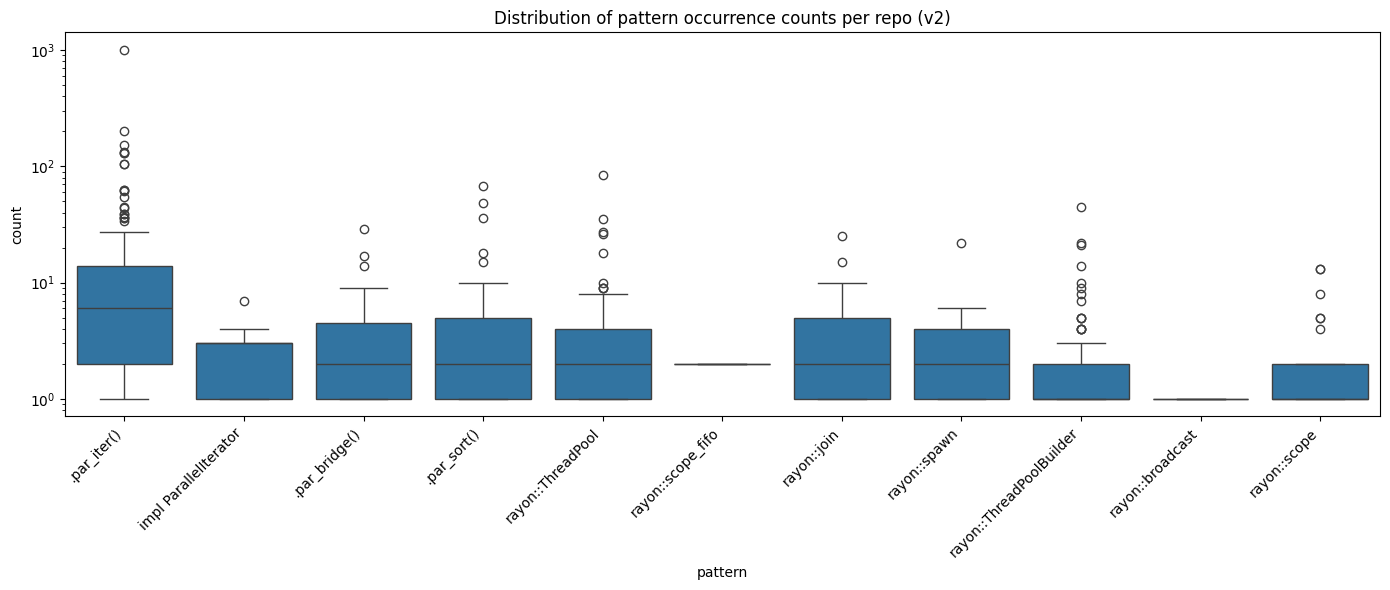

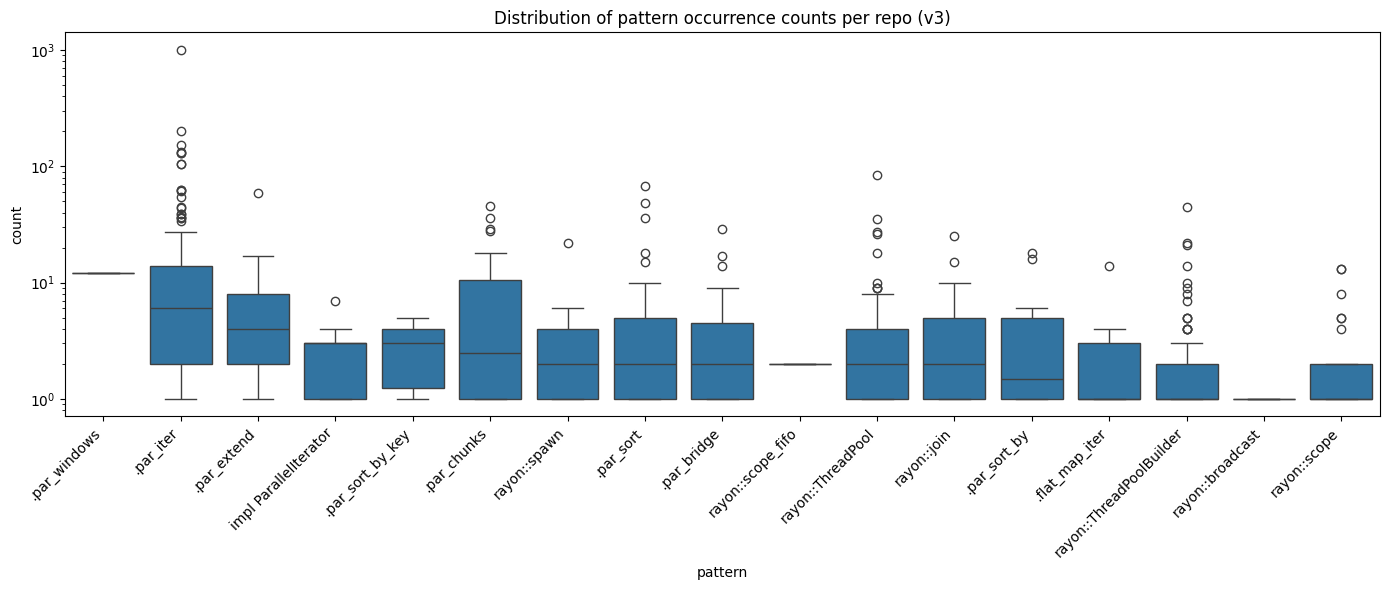

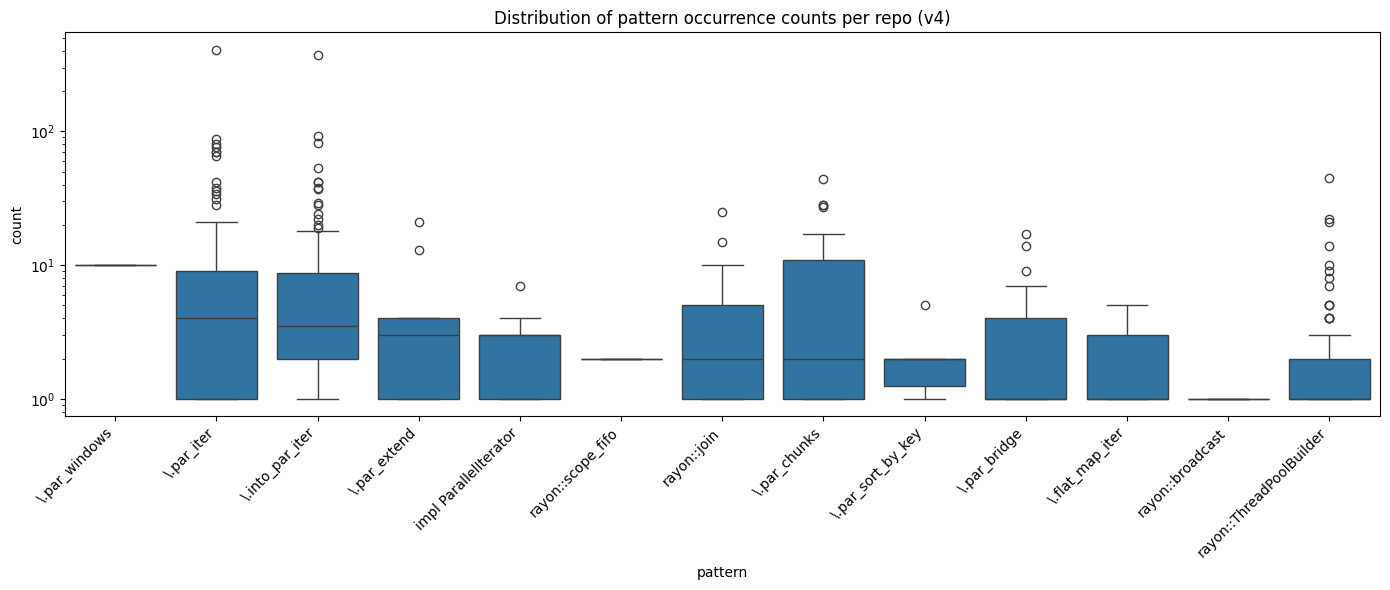

In [52]:
outlier_analysis(1)
outlier_analysis(2)
outlier_analysis(3)
outlier_analysis(4)


=== Repo differences (v1 -> v3) ===
Repos lost:   11
Repos gained: 0

Lost repos and their patterns in v1:
  Canop/broot:
    ThreadPool                          4
    reduce                              3
    ThreadPoolBuilder                   2
  ImageOptim/gifski:
    reduce                              2
  PyO3/pyo3:
    reduce                              11
  bahdotsh/wrkflw:
    reduce                              3
    unzip                               3
  facebook/buck2:
    reduce                              49
    unzip                               15
    ThreadPool                          9
  fitzgen/bumpalo:
    reduce                              1
  luminal-ai/luminal:
    reduce                              118
    ThreadPool                          30
  memvid/memvid:
    reduce                              5
  salsa-rs/salsa:
    reduce                              5
  sigoden/aichat:
    unzip                               9
  typedb/typedb:
    reduce       

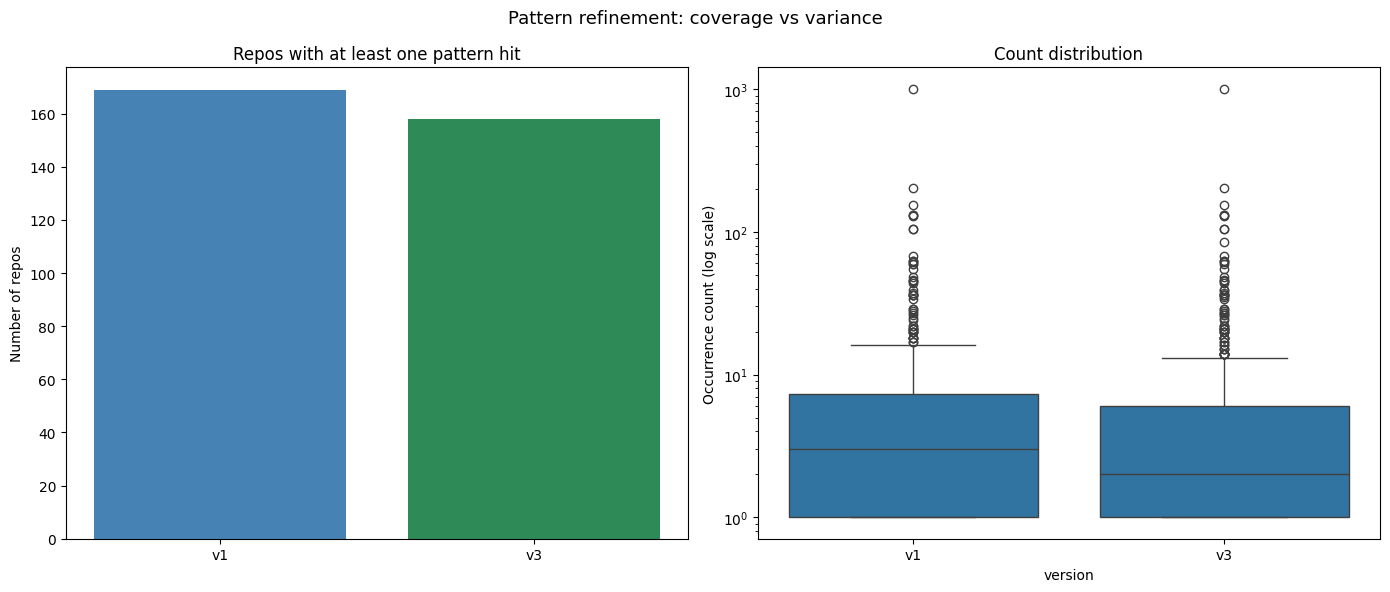

In [53]:
effectiveness_comparison(1, 3)


=== Repo differences (v2 -> v3) ===
Repos lost:   0
Repos gained: 2

Gained repos and their patterns in v3:
  image-rs/image:
    .par_chunks                         2
  massalabs/massa:
    .par_chunks                         1


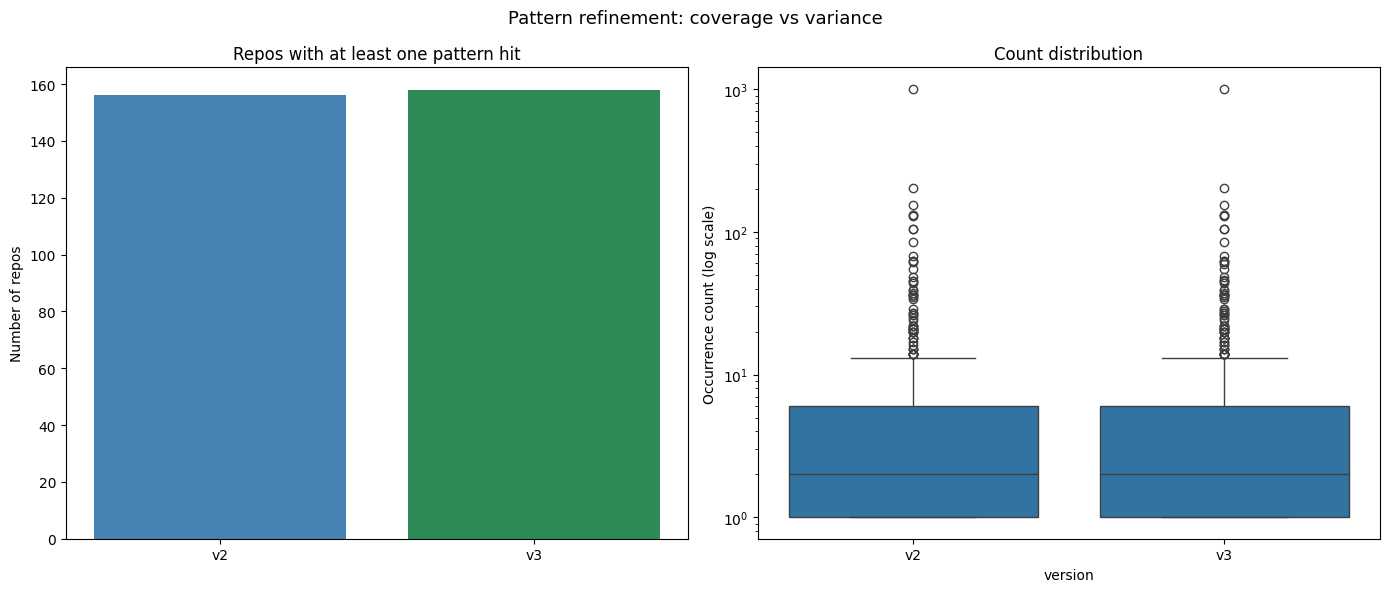

In [54]:
effectiveness_comparison(2, 3)


=== Repo differences (v3 -> v4) ===
Repos lost:   4
Repos gained: 0

Lost repos and their patterns in v3:
  agersant/polaris:
    .par_sort                           3
    rayon::ThreadPool                   1
  dimforge/nalgebra:
    .par_iter                           1
  lapce/lapce:
    rayon::spawn                        4
  rust-lang-nursery/rust-cookbook:
    .par_sort                           2


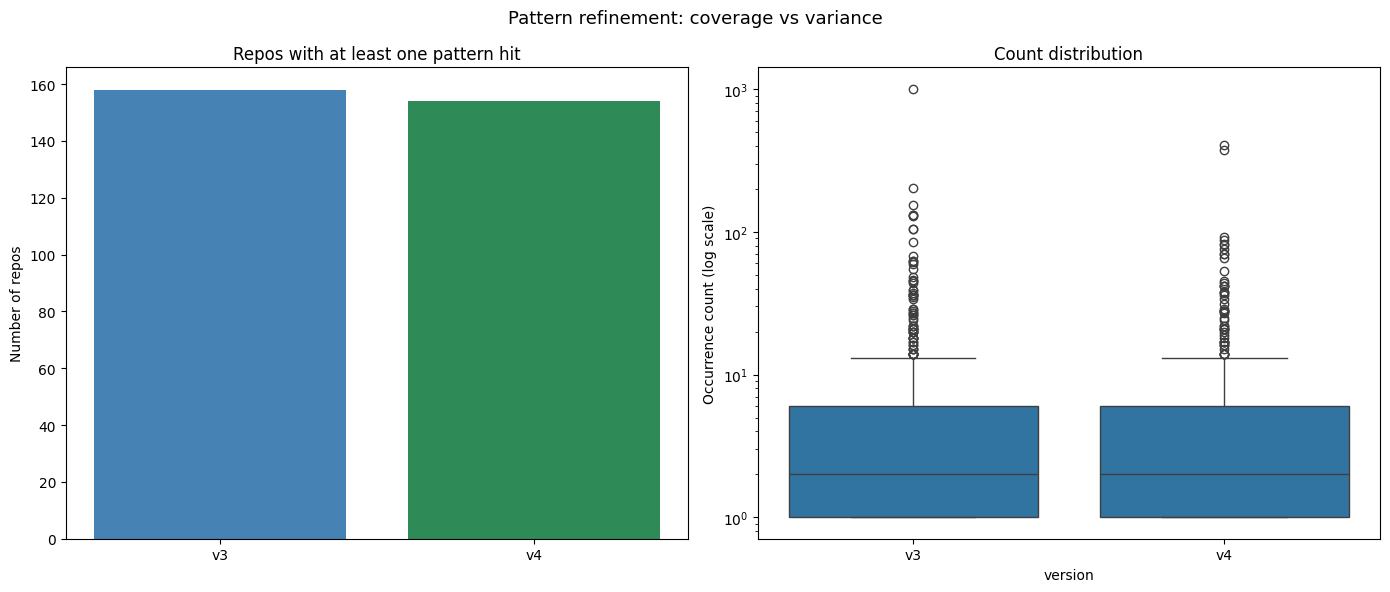

In [65]:
effectiveness_comparison(3, 4)

In [70]:
def compute_repo_scores():
    df = pd.read_json("../data/analysis_4.json")
    df_patterns = df.explode('patterns').dropna(subset=['patterns'])
    df_patterns[['pattern', 'count']] = df_patterns['patterns'].apply(pd.Series)

    complex_patterns = [
        'rayon::scope', 'rayon::scope_fifo', 'rayon::join',
        'rayon::spawn', 'rayon::ThreadPoolBuilder', 'rayon::ThreadPool',
        'impl ParallelIterator', 'rayon::broadcast'
    ]

    complex_repos = set(df_patterns[df_patterns['pattern'].isin(complex_patterns)]['full_name'])

    scores = df_patterns.groupby('full_name').agg(
        pattern_diversity=('pattern', 'nunique'),
    ).reset_index()    

    scores = scores.merge(df[['full_name', 'stargazers_count', 'unsafe_in_rayon_files']], on='full_name')
    scores['has_complex'] = scores['full_name'].isin(complex_repos).astype(float)

    for col in ['pattern_diversity', 'stargazers_count', 'unsafe_in_rayon_files']:
        scores[f'{col}_norm'] = (scores[col] - scores[col].min()) / (scores[col].max() - scores[col].min())

    scores['final_score'] = (
        scores['has_complex'] * 0.25 +
        scores['pattern_diversity_norm'] * 0.25 +
        scores['stargazers_count_norm'] * 0.25 +
        scores['unsafe_in_rayon_files_norm'] * 0.25
    )

    scores = scores.sort_values('final_score', ascending=False)
    scores.to_json("../data/repo_scores.json", orient='records', indent=2)
    print(f"Saved {len(scores)} repo scores")
    print(scores[['full_name', 'has_complex', 'pattern_diversity', 'stargazers_count', 'final_score']].head(20))

In [69]:
def print_repo_summary(full_name: str):
    df = pd.read_json("../data/analysis_4.json")
    repo = df[df['full_name'] == full_name].iloc[0]
    
    print(f"Repository:   {repo['full_name']}")
    print(f"Stars:        {repo['stargazers_count']}")
    print(f"Unsafe count: {repo['unsafe_in_rayon_files']}")
    print(f"\nPatterns found:")
    for p in sorted(repo['patterns'], key=lambda x: x['count'], reverse=True):
        print(f"  {p['pattern']:<30} {p['count']}")

In [71]:
compute_repo_scores()

Saved 154 repo scores
                     full_name  has_complex  pattern_diversity  \
102             pola-rs/polars          1.0                  8   
107             rayon-rs/rayon          1.0                 12   
36                astral-sh/uv          1.0                  3   
153         zed-industries/zed          1.0                  3   
119            ruvnet/RuVector          1.0                  6   
139                typst/typst          1.0                  5   
146            warpdotdev/warp          1.0                  4   
11               FuelLabs/sway          1.0                  3   
35              astral-sh/ruff          1.0                  4   
122                servo/servo          1.0                  4   
134            swc-project/swc          1.0                  5   
151           wild-linker/wild          1.0                  7   
94             nushell/nushell          1.0                  4   
43   bytecodealliance/wasmtime          1.0           

In [72]:
print_repo_summary("pola-rs/polars")

Repository:   pola-rs/polars
Stars:        38364
Unsafe count: 390

Patterns found:
  \.into_par_iter                92
  \.par_iter                     70
  rayon::join                    15
  impl ParallelIterator          3
  \.par_sort_by_key              2
  \.par_chunks                   1
  \.par_bridge                   1
  \.par_extend                   1


In [77]:
import subprocess
import random

def repo_instance_overview(full_name: str, n_sample: int = 10, seed=42):
    random.seed(seed)
    repo_path = f"../data/repositories/{full_name.replace('/', '_')}"
    
    df = pd.read_json("../data/analysis_4.json")
    repo = df[df['full_name'] == full_name].iloc[0]
    patterns = {p['pattern']: p['count'] for p in repo['patterns']}
    
    complex_patterns = {
        'rayon::scope', 'rayon::scope_fifo', 'rayon::join',
        'rayon::spawn', 'rayon::ThreadPoolBuilder', 'rayon::ThreadPool',
        'impl ParallelIterator', 'rayon::broadcast'
    }

    print(f"=== {full_name} ===\n")

    for pattern, count in sorted(patterns.items(), key=lambda x: x[1], reverse=True):
        is_complex = pattern in complex_patterns
        
        print(f"--- {pattern} ({count} hits) {'[COMPLEX]' if is_complex else ''} ---")
        
        result = subprocess.run(
            ["rg", "--type", "rust", "-l", pattern, repo_path],
            capture_output=True, text=True
        )
        files = result.stdout.strip().split('\n')
        files = sorted([f for f in files if f])        

        if is_complex:
            for file in files:
                result = subprocess.run(
                    ["rg", "--type", "rust", "-n", pattern, file],
                    capture_output=True, text=True
                )
                rel_path = file.replace(repo_path + '/', '')
                for line in result.stdout.strip().split('\n'):
                    if line:
                        print(f"  {rel_path}: {line}")
        else:
            sampled_files = random.sample(files, min(n_sample, len(files)))

            for file in sampled_files:
                result = subprocess.run(
                    ["rg", "--type", "rust", "-n", pattern, file],
                    capture_output=True, text=True
                )
                rel_path = file.replace(repo_path + '/', '')
                first_hit = result.stdout.strip().split('\n')[0]
                if first_hit:
                    print(f"  {rel_path}: {first_hit}")

        print()

In [78]:
repo_instance_overview("pola-rs/polars")

=== pola-rs/polars ===

--- \.into_par_iter (92 hits)  ---
  crates/polars-plan/src/plans/conversion/dsl_to_ir/scans.rs: 583:                .into_par_iter()
  crates/polars-core/src/frame/group_by/aggregations/categorical.rs: 17:                        .into_par_iter()
  crates/polars-core/src/chunked_array/from_iterator_par.rs: 36:    let it = par_iter.into_par_iter();
  crates/polars-expr/src/dispatch/groups_dispatch.rs: 45:                .into_par_iter()
  crates/polars-core/src/hashing/vector_hasher.rs: 487:        keys.into_par_iter()
  crates/polars-core/src/frame/row/transpose.rs: 237:        .into_par_iter()
  crates/polars-core/src/frame/group_by/aggregations/dispatch.rs: 316:                .into_par_iter()
  crates/polars-core/src/frame/group_by/aggregations/boolean.rs: 11:    let ca: BooleanChunked = POOL.install(|| groups.into_par_iter().map(f).collect());
  crates/polars-ops/src/frame/join/hash_join/single_keys_inner.rs: 80:            .into_par_iter()
  crates/polars-c